# Q6 — Top Job Priority Breakdown vs. Satisfaction Level

**Question:** How common is each top job priority, and how does it relate to satisfaction?

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110

OUT = Path("charts")
OUT.mkdir(exist_ok=True)

# Load and clean - same cleaning decision made in the SQL phase:
# blank education values become the literal string 'None'
df = pd.read_csv("DataProfessionalSurvey_Clean.csv")
df["education"] = df["education"].fillna("None")
df["country"] = df["country"].str.strip()
df["role_name"] = df["role_name"].str.strip()

print(f"{len(df)} respondents loaded.")
df.head()

630 respondents loaded.


,respondent_id,date_taken,time_taken,time_spent,role_name,switched_careers,salary_band,salary_midpoint,industry,fav_language,...,satisfaction_mobility,satisfaction_learning,satisfaction_composite,difficulty_breaking_in,top_job_priority,gender,age,country,education,ethnicity
0,62a33b3db4da29969c62df3d,6/10/2022,8:38,0:00:44,Data Analyst,Yes,106-125,115500,Healthcare,Python,...,5.00,7.00,7.00,Very Difficult,Remote Work,Male,26,United States,None,White
1,62a33ba1bae91e4b8b82e35c,6/10/2022,8:40,0:01:30,Data Analyst,No,41-65,53000,Finance,R,...,1.00,3.00,2.33,Very Difficult,Remote Work,Male,36,Canada,None,Asian
2,62a33c2cbc6861bf3176bec1,6/10/2022,8:42,0:02:18,Data Engineer,No,0-40,20000,Other,Python,...,7.00,7.00,5.67,Easy,Good Work/Life Balance,Male,23,Rest of the world,None,Black
3,62a33c8624a26260273822f9,6/10/2022,8:43,0:02:10,Other,Yes,150 - 225,187500,Finance,R,...,7.00,10.00,8.33,Very Easy,Remote Work,Female,35,Canada,None,White
4,62a33c91f3072dd892621e03,6/10/2022,8:44,0:01:51,Data Analyst,Yes,41 - 65,53000,Healthcare,R,...,0.00,1.00,2.33,Difficult,Better Salary,Male,44,United States,None,Black


In [2]:
job_priority = df.groupby("top_job_priority").agg(
    n=("respondent_id", "count"),
    pct_of_respondents=("respondent_id", lambda s: len(s) / len(df) * 100),
    mean_composite_satisfaction=("satisfaction_composite", "mean"),
    mean_salary_satisfaction=("satisfaction_salary", "mean"),
    mean_worklife_satisfaction=("satisfaction_worklife", "mean"),
).sort_values("n", ascending=False)
job_priority

,n,pct_of_respondents,mean_composite_satisfaction,mean_salary_satisfaction,mean_worklife_satisfaction
top_job_priority,,,,,
Better Salary,297,47.14,5.15,3.84,5.88
Remote Work,127,20.16,5.53,4.39,5.79
Good Work/Life Balance,117,18.57,4.95,4.55,4.93
Good Culture,54,8.57,5.42,5.17,6.15
other,35,5.56,5.80,5.26,6.41


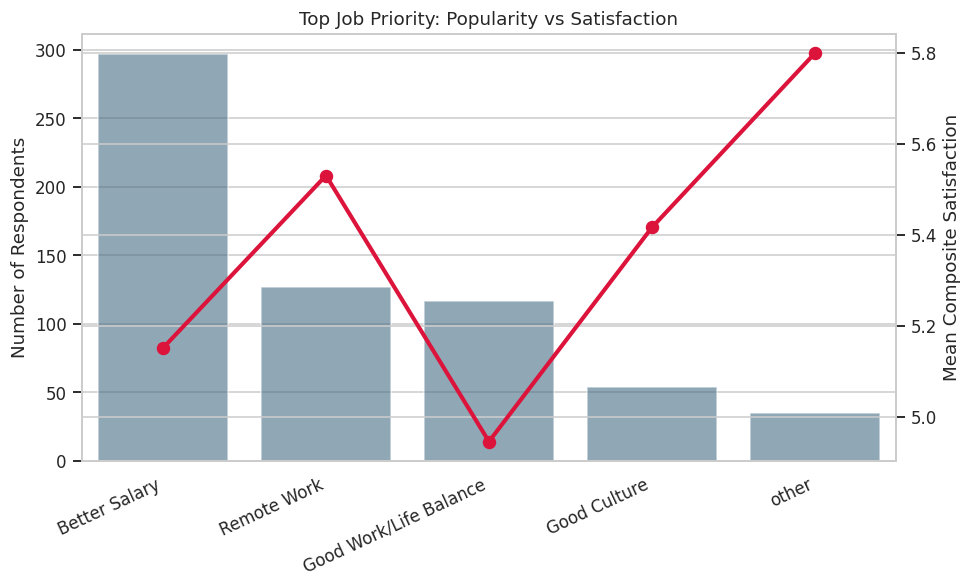

In [3]:
fig, ax1 = plt.subplots(figsize=(9, 5.5))
data = job_priority.reset_index()

sns.barplot(data=data, x="top_job_priority", y="n", ax=ax1, color="#3b6f8f", alpha=0.6)
ax1.set_ylabel("Number of Respondents")
ax1.set_xlabel("")
plt.setp(ax1.get_xticklabels(), rotation=25, ha="right")

ax2 = ax1.twinx()
sns.pointplot(data=data, x="top_job_priority", y="mean_composite_satisfaction",
              ax=ax2, color="crimson")
ax2.set_ylabel("Mean Composite Satisfaction")
ax1.set_title("Top Job Priority: Popularity vs Satisfaction")

fig.tight_layout()
fig.savefig(OUT / "q6_job_priority_vs_satisfaction.png", bbox_inches="tight")
plt.show()

**Takeaway:** 'Better Salary' is the most common top priority (47% of respondents) but also has below-average composite satisfaction — consistent with salary being the biggest satisfaction drag (see Q2).

# Q6b — Top Job Priority vs Bucketed Satisfaction Level (Low/Medium/High)

**Question:** Does the most common top job priority differ depending on whether someone's overall satisfaction is Low, Medium, or High?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110

OUT = Path("charts")
OUT.mkdir(exist_ok=True)

df = pd.read_csv("DataProfessionalSurvey_Clean.csv")
df["education"] = df["education"].fillna("None")
df["country"] = df["country"].str.strip()
df["role_name"] = df["role_name"].str.strip()

DIMS = ["satisfaction_salary", "satisfaction_worklife", "satisfaction_coworkers",
        "satisfaction_management", "satisfaction_mobility", "satisfaction_learning"]

print(f"{len(df)} respondents loaded.")
df.head()

630 respondents loaded.


,respondent_id,date_taken,time_taken,time_spent,role_name,switched_careers,salary_band,salary_midpoint,industry,fav_language,...,satisfaction_mobility,satisfaction_learning,satisfaction_composite,difficulty_breaking_in,top_job_priority,gender,age,country,education,ethnicity
0,62a33b3db4da29969c62df3d,6/10/2022,8:38,0:00:44,Data Analyst,Yes,106-125,115500,Healthcare,Python,...,5.00,7.00,7.00,Very Difficult,Remote Work,Male,26,United States,None,White
1,62a33ba1bae91e4b8b82e35c,6/10/2022,8:40,0:01:30,Data Analyst,No,41-65,53000,Finance,R,...,1.00,3.00,2.33,Very Difficult,Remote Work,Male,36,Canada,None,Asian
2,62a33c2cbc6861bf3176bec1,6/10/2022,8:42,0:02:18,Data Engineer,No,0-40,20000,Other,Python,...,7.00,7.00,5.67,Easy,Good Work/Life Balance,Male,23,Rest of the world,None,Black
3,62a33c8624a26260273822f9,6/10/2022,8:43,0:02:10,Other,Yes,150 - 225,187500,Finance,R,...,7.00,10.00,8.33,Very Easy,Remote Work,Female,35,Canada,None,White
4,62a33c91f3072dd892621e03,6/10/2022,8:44,0:01:51,Data Analyst,Yes,41 - 65,53000,Healthcare,R,...,0.00,1.00,2.33,Difficult,Better Salary,Male,44,United States,None,Black


### Bucket composite satisfaction into Low (0-4) / Medium (4-7) / High (7-10)

In [2]:
def bucket_satisfaction(score):
    if score < 4:
        return "Low (0-4)"
    elif score < 7:
        return "Medium (4-7)"
    else:
        return "High (7-10)"

df["satisfaction_bucket"] = df["satisfaction_composite"].apply(bucket_satisfaction)

bucket_order = ["Low (0-4)", "Medium (4-7)", "High (7-10)"]
priority_by_bucket = pd.crosstab(df["satisfaction_bucket"], df["top_job_priority"])
priority_by_bucket = priority_by_bucket.reindex(bucket_order)
priority_by_bucket

top_job_priority,Better Salary,Good Culture,Good Work/Life Balance,Remote Work,other
satisfaction_bucket,,,,,
Low (0-4),83,15,40,29,3
Medium (4-7),143,24,43,55,24
High (7-10),71,15,34,43,8


### Same table as row percentages (easier to compare shape across buckets)

In [4]:
priority_by_bucket_pct = (
    pd.crosstab(df["satisfaction_bucket"], df["top_job_priority"], normalize="index") * 100
).reindex(bucket_order).round(1)
priority_by_bucket_pct

top_job_priority,Better Salary,Good Culture,Good Work/Life Balance,Remote Work,other
satisfaction_bucket,,,,,
Low (0-4),48.80,8.80,23.50,17.10,1.80
Medium (4-7),49.50,8.30,14.90,19.00,8.30
High (7-10),41.50,8.80,19.90,25.10,4.70


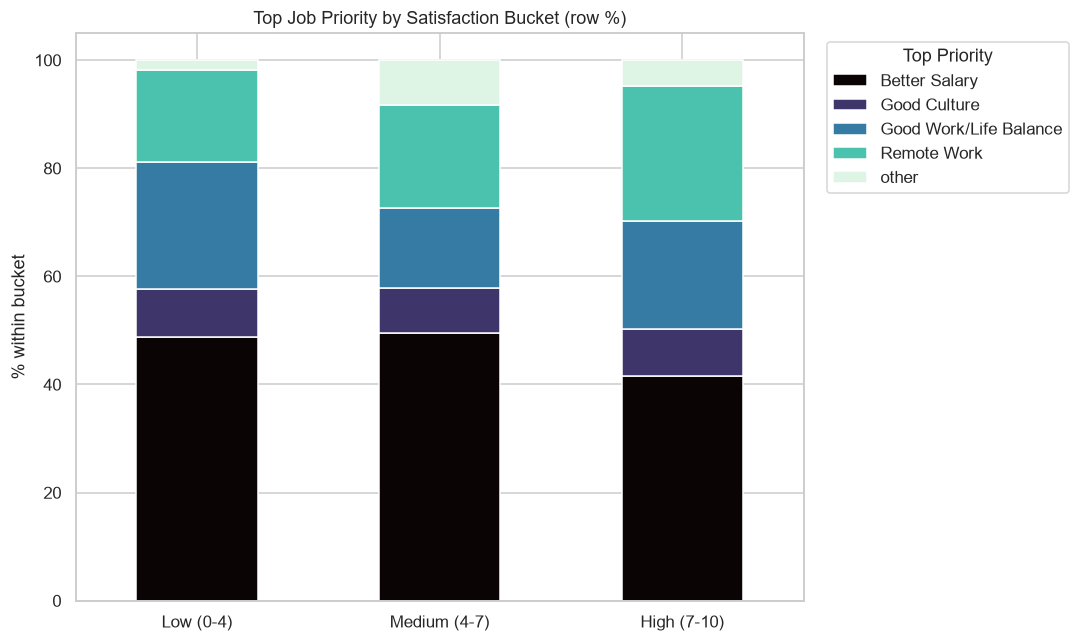

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
priority_by_bucket_pct.plot(kind="bar", stacked=True, ax=ax, colormap="mako")
ax.set_title("Top Job Priority by Satisfaction Bucket (row %)")
ax.set_ylabel("% within bucket")
ax.set_xlabel("")
plt.xticks(rotation=0)
ax.legend(title="Top Priority", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(OUT / "q6b_priority_by_satisfaction_bucket.png", bbox_inches="tight")
plt.show()

**Takeaway:** 'Better Salary' stays the top priority across all three satisfaction buckets, but its share shifts — worth checking whether it grows as a share of the Low-satisfaction bucket specifically, which would reinforce the Q2 finding that salary satisfaction is the biggest composite drag.